# Exercise 6.5

### Importing libraries and data

In [79]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import os
import sklearn
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pylab as pl

In [81]:
%matplotlib inline

In [83]:
path = r'C:/Users/jeffr/Documents/Medical Costs Analysis'

In [85]:
df = pd.read_csv(os.path.join(path, '02 Data', 'Prepared Data', 'insurance.csv'))

In [87]:
df.shape

(1337, 7)

In [17]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,West,16884.92400
1,18,male,33.770,1,no,South,1725.55230
2,28,male,33.000,3,no,South,4449.46200
3,33,male,22.705,0,no,Midwest,21984.47061
4,32,male,28.880,0,no,Midwest,3866.85520


In [105]:
# creating a subset with only numeric variables
df1 = df[['age', 'bmi', 'children', 'charges']]

In [107]:
df1.head()

,age,bmi,children,charges
0,19.0,27.900,0,16884.92400
1,18.0,33.770,1,1725.55230
2,28.0,33.000,3,4449.46200
3,33.0,22.705,0,21984.47061
4,32.0,28.880,0,3866.85520


In [93]:
df['age'] = df['age'].astype(np.float64)

In [95]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1337 entries, 0 to 1336
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   float64
 1   sex       1337 non-null   object 
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   object 
 5   region    1337 non-null   object 
 6   charges   1337 non-null   float64
dtypes: float64(3), int64(1), object(3)
memory usage: 73.2+ KB
None


### Elbow Technique

In [99]:
num_cl = range(1, 10)
kmeans = [KMeans(n_clusters=i) for i in num_cl]

In [111]:
score = [kmeans[i].fit(df1).score(df1) for i in range(len(kmeans))]
score

C:\Users\jeffr\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\jeffr\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\jeffr\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\jeffr\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

[-195939158682.99286,
 -47972418691.2541,
 -23029166491.109802,
 -12119684051.919432,
 -8535631071.070277,
 -6178801958.4806,
 -4441212620.961626,
 -4162467634.4068904,
 -2789084524.9715047]

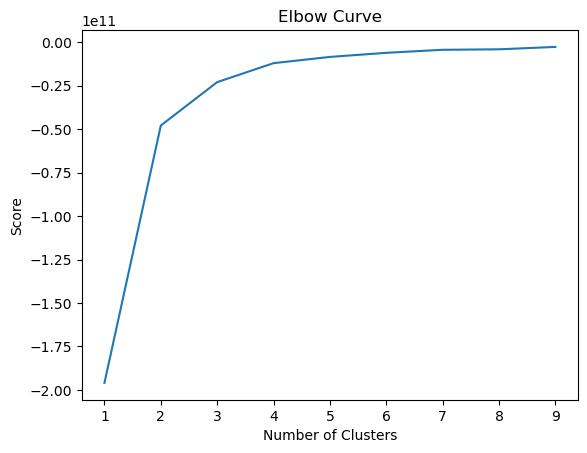

In [113]:
# Plot the elbow curve using PyLab
pl.plot(num_cl,score)
pl.xlabel('Number of Clusters')
pl.ylabel('Score')
pl.title('Elbow Curve')
pl.show()

#### Based on the the elbow and the liner regression from the previous exercise, I knew I wanted to use 3 clusters for the kmeans

### k-means clustering

In [116]:
# Create the k-means object
kmeans = KMeans(n_clusters = 3)

In [118]:
# Fit the k-means object to the data
kmeans.fit(df1)

C:\Users\jeffr\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


KMeans(n_clusters=3)

In [120]:
df1['clusters'] = kmeans.fit_predict(df1)

C:\Users\jeffr\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\jeffr\AppData\Local\Temp\ipykernel_17412\865444660.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['clusters'] = kmeans.fit_predict(df1)


In [122]:
df1.head()

,age,bmi,children,charges,clusters
0,19.0,27.900,0,16884.92400,0
1,18.0,33.770,1,1725.55230,2
2,28.0,33.000,3,4449.46200,2
3,33.0,22.705,0,21984.47061,0
4,32.0,28.880,0,3866.85520,2


In [124]:
df1['clusters'].value_counts()

clusters
2    786
0    380
1    171
Name: count, dtype: int64

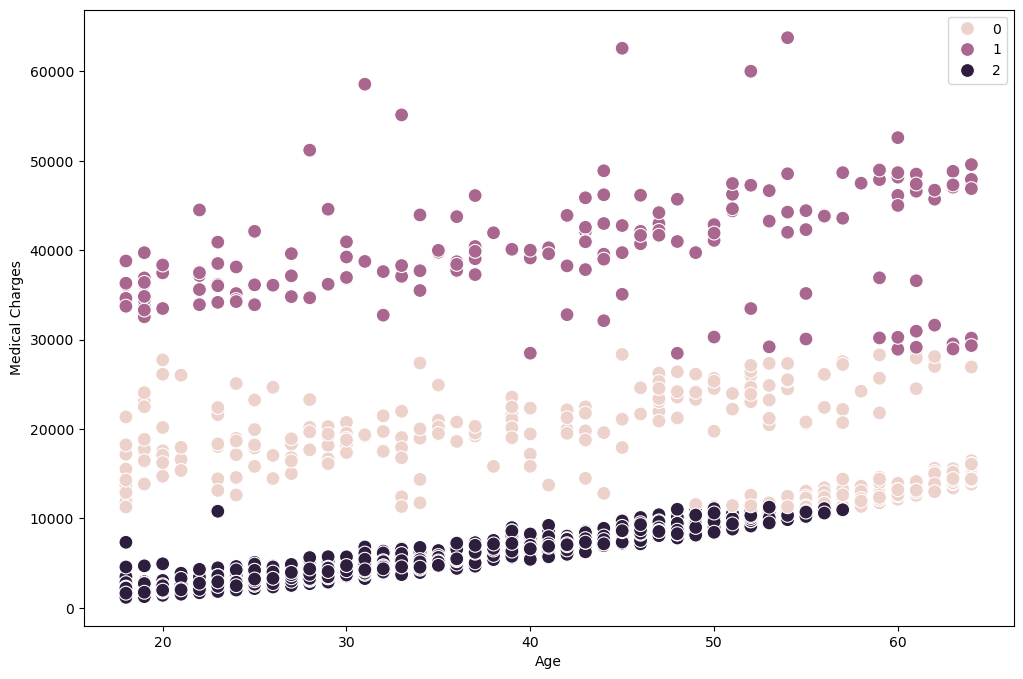

In [126]:
# Plot the clusters for 'Age' and 'charges variables

plt.figure(figsize=(12,8))
ax = sns.scatterplot(x=df1['age'], y=df1['charges'], hue=kmeans.labels_, s=100)
ax.grid(False)
plt.xlabel('Age')
plt.ylabel('Medical Charges')
plt.show()

#### This visual to me doesn't really show any thing new.  Seeing 3 clusters based on charges and each cluster does go up or increase in charges as the age increases showing a positive relationship between all three clusters.

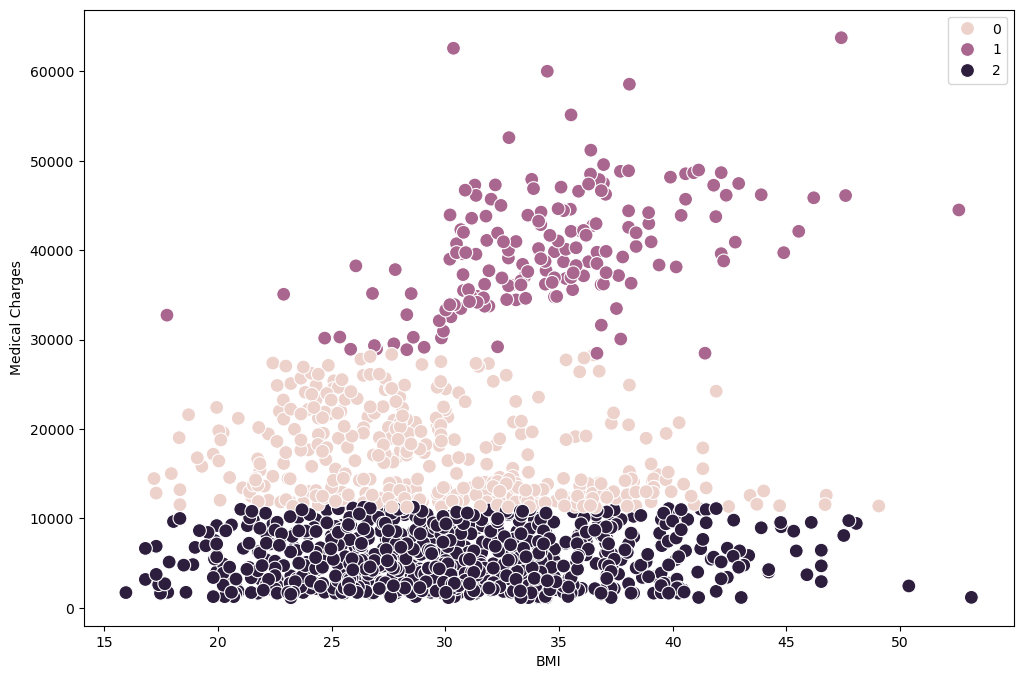

In [128]:
# Plot the clusters for "bmi" and "charges" variables
plt.figure(figsize=(12,8))
ax = sns.scatterplot(x=df1['bmi'], y=df1['charges'], hue=kmeans.labels_, s=100)
ax.grid(False)
plt.xlabel('BMI')
plt.ylabel('Medical Charges')
plt.show()

Clusters are based on Charges. 0-1000, 1000-3000, and 3000 and above.  The first two are pretty spread out across the bmi.  However the third cluster shows those with a bmi between 30 - 40 have higher medical charges.

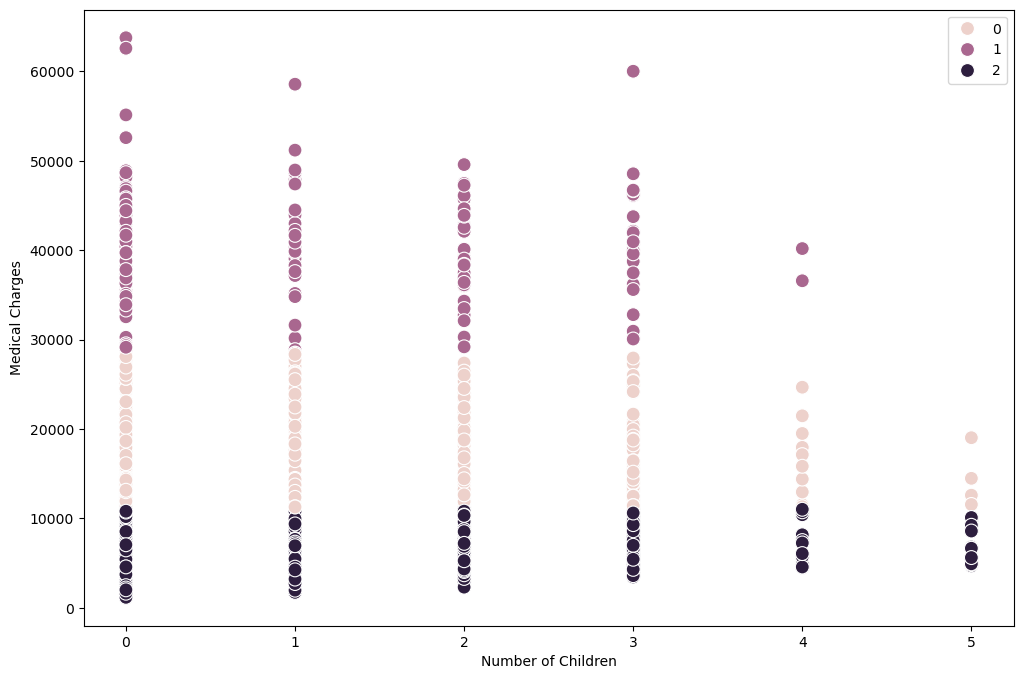

In [133]:
#Plot the clusters for the "children" and "charges" variables
plt.figure(figsize=(12,8))
ax = sns.scatterplot(x=df1['children'], y=df1['charges'], hue=kmeans.labels_, s=100)
ax.grid(False)
plt.xlabel('Number of Children')
plt.ylabel('Medical Charges')
plt.show()

#### Here we see three clusters again by medical charges. It appears those with the most children and least amount of medical charges however also fewer people have 4 and above number of children.  The highest number of those with the highest amount of medical charges tend to have 0 children or those that are dependants on the insurance which could signify older adults with adult children.  Seems an even spread of medical charges when it comes to those with 1-3 children.

### Calculate descriptive statistics for clusters using groupby() function

In [137]:
df1.loc[df1['clusters'] == 2, 'cluster'] = 'dark purple'
df1.loc[df1['clusters'] == 1, 'cluster'] = 'purple'
df1.loc[df1['clusters'] == 0, 'cluster'] = 'pink'

C:\Users\jeffr\AppData\Local\Temp\ipykernel_17412\2078207149.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1.loc[df1['clusters'] == 2, 'cluster'] = 'dark purple'


In [141]:
df1.groupby('cluster').agg({'age':['mean', 'median'],
                           'bmi':['mean', 'median'],
                           'children':['mean', 'median'],
                           'charges':['mean', 'median']})

age               bmi           children         \
                  mean median       mean   median      mean median   
cluster                                                              
dark purple  34.937659   35.0  30.351654  30.0300  1.097964    1.0   
pink         47.171053   54.0  29.527526  28.5475  1.073684    1.0   
purple       41.251462   43.0  34.620906  34.4300  1.134503    1.0   

                  charges                
                     mean        median  
cluster                                  
dark purple   5730.082334   5420.342275  
pink         16805.628450  14702.206575  
purple       40141.531590  39722.746200

#### The mean and median for the age clusters follow expected patterns. Except that the purple cluster which represents the cluster with the highes medical charges does not have the highest average age, that belongs to the pink.  

#### The mean and median decrease slighty with the pink cluster when is the 10000-30000 group of charges.  However the purple cluster of charges 30000 and above does correspond to the higher average bmi.

#### The mean and median are all the same at 1. 

#### For charges, the cluster colors match what the visuals show.  The dark purple being the cluster of those with the least amount of charges, pink cluster second highest of charges from 10000 - 30000, and then purple being the cluster of the highest amount of charges of 30000 and above.

#### As we futher analyize the data and investigate the region with the highest number of people with high medical charges, we know that they tend to be in their 40s with higher bmi.  The next step would be to see if there is any relationship between higher medical charges and smoker status and sex.